# *Data Cleaning & Clustering Pipeline*

This notebook covers the full pipeline:
1. Data Loading & Exploration
2. Missing Values & Duplicates
3. Outlier Detection & Removal
4. Scaling
5. PCA Visualization
6. K-Means Clustering
7. Autoencoder + K-Means
8. DBSCAN
9. GMM (Gaussian Mixture Models)
10. SOM (Self-Organizing Maps)

## Imports

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# MiniSOM
from minisom import MiniSom
from itertools import product

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print('✅ All imports done')

✅ All imports done


## Data Loading & Exploration

Load the raw Credit Card dataset and get a first look at its shape, types, and basic statistics.

In [96]:
df = pd.read_csv(r"c:\Users\aa\Downloads\Credit_Card.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (12240, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C30077,1138.82,0.87,6974.45,679.13,2760.79,111.80,0.89,0.18,0.73,0.06,1,21,4303.00,2340.57,435.05,0.07,12
1,C29345,2356.82,0.98,8051.39,5596.14,3478.67,0.00,0.91,0.56,0.56,0.07,1,43,7900.00,2332.23,273.08,0.97,12
2,C23726,2944.24,0.97,7420.29,6770.43,1467.75,318.21,0.93,0.67,0.63,0.00,0,28,11044.00,6982.66,786.22,0.40,12
3,C28521,25.62,0.47,354.43,0.00,62.80,85.57,0.05,0.20,0.04,0.01,0,1,2386.00,371.60,325.19,0.06,12
4,C30497,238.61,0.01,248.83,129.86,56.36,0.00,0.05,0.02,0.01,0.05,1,1,1930.00,348.40,205.10,0.17,12


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12240 entries, 0 to 12239
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           12240 non-null  object 
 1   BALANCE                           11878 non-null  float64
 2   BALANCE_FREQUENCY                 12240 non-null  float64
 3   PURCHASES                         11874 non-null  float64
 4   ONEOFF_PURCHASES                  12240 non-null  float64
 5   INSTALLMENTS_PURCHASES            12240 non-null  float64
 6   CASH_ADVANCE                      11996 non-null  float64
 7   PURCHASES_FREQUENCY               12240 non-null  float64
 8   ONEOFF_PURCHASES_FREQUENCY        12240 non-null  float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  12240 non-null  float64
 10  CASH_ADVANCE_FREQUENCY            12240 non-null  float64
 11  CASH_ADVANCE_TRX                  12240 non-null  int64  
 12  PURC

In [98]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,11878.00,2207.43,4180.63,0.00,194.31,1146.27,3288.02,59718.82
BALANCE_FREQUENCY,12240.00,0.66,0.32,0.00,0.35,0.82,0.95,1.00
PURCHASES,11874.00,3166.45,5945.99,0.00,200.52,465.44,4939.07,79580.36
ONEOFF_PURCHASES,12240.00,1230.56,2317.14,0.00,104.78,243.17,524.23,10935.66
INSTALLMENTS_PURCHASES,12240.00,1583.37,1894.00,0.00,67.90,203.90,3357.66,7305.41
CASH_ADVANCE,11996.00,1335.51,3653.58,0.00,8.79,108.98,324.96,49976.18
PURCHASES_FREQUENCY,12240.00,0.46,0.36,0.00,0.15,0.26,0.88,1.05
ONEOFF_PURCHASES_FREQUENCY,12240.00,0.21,0.25,0.00,0.06,0.12,0.20,1.02
PURCHASES_INSTALLMENTS_FREQUENCY,12240.00,0.35,0.34,0.00,0.07,0.14,0.71,1.05
CASH_ADVANCE_FREQUENCY,12240.00,0.16,0.26,0.00,0.02,0.04,0.08,0.91


## Handle Missing & Duplicated Values

First we identify which columns have missing values and what percentage they represent. Then we remove exact duplicate rows, and finally impute remaining nulls with the **median** (robust to outliers).

In [99]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality_report = pd.DataFrame({
    'Missing Count' : missing,
    'Missing %'     : missing_pct
}).query('`Missing Count` > 0')

print('Missing Values:')
print(quality_report.to_string())
print(f"Duplicate rows: {df.duplicated().sum()}")

Missing Values:
                  Missing Count  Missing %
BALANCE                     362       2.96
PURCHASES                   366       2.99
CASH_ADVANCE                244       1.99
CREDIT_LIMIT                496       4.05
MINIMUM_PAYMENTS            860       7.03
Duplicate rows: 229


In [100]:
# Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
after  = len(df)
print(f"Rows before : {before}")
print(f"Rows removed: {before - after}")
print(f"Rows after  : {after}")

Rows before : 12240
Rows removed: 229
Rows after  : 12011


In [101]:
# Impute missing values with column median
df = df.fillna(df.median(numeric_only=True))
print('Missing after imputation:')
print(df.isnull().sum().sum())

Missing after imputation:
0


## Outlier Detection & Handling

We use the **IQR method** with a multiplier of 3.0 (conservative — only extreme outliers). Detected outliers are handled via **Winsorization** (clipping to the IQR bounds) rather than removal, so no data is lost.

In [102]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

def detect_outliers_iqr(df, col, multiplier=3.0):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return outliers.index, lower, upper

print(f"{'Column':<35} {'Outliers':>10} {'Lower':>12} {'Upper':>12}")
print("-" * 72)

outlier_summary = {}
for col in numeric_cols:
    idx, low, up = detect_outliers_iqr(df, col)
    if len(idx) > 0:
        outlier_summary[col] = idx
        print(f"{col:<35} {len(idx):>10,} {low:>12.2f} {up:>12.2f}")

print(f"\nTotal outlier rows detected: {len(set([i for idx in outlier_summary.values() for i in idx])):,}")

Column                                Outliers        Lower        Upper
------------------------------------------------------------------------
BALANCE                                     80     -8782.19     12179.35
PURCHASES                                   80    -13754.46     18818.17
ONEOFF_PURCHASES                         2,058     -1153.11      1783.44
CASH_ADVANCE                             2,645      -892.23      1214.12
ONEOFF_PURCHASES_FREQUENCY               1,720        -0.35         0.61
CASH_ADVANCE_FREQUENCY                   2,568        -0.18         0.28
CASH_ADVANCE_TRX                         1,571        -6.00         8.00
CREDIT_LIMIT                                12    -10952.50     19690.00
PAYMENTS                                   200     -7354.09     10512.80
MINIMUM_PAYMENTS                           449      -912.51      1719.53
PRC_FULL_PAYMENT                         1,637        -0.34         0.50
TENURE                                   1,785     

In [103]:
df_clean = df.copy()
for col, idx in outlier_summary.items():
    _, low, up = detect_outliers_iqr(df, col)
    df_clean[col] = df_clean[col].clip(lower=low, upper=up)
    print(f"{col:<35} → clipped to [{low:.2f}, {up:.2f}]")

print(f"\nDone! Shape: {df_clean.shape}")

BALANCE                             → clipped to [-8782.19, 12179.35]
PURCHASES                           → clipped to [-13754.46, 18818.17]
ONEOFF_PURCHASES                    → clipped to [-1153.11, 1783.44]
CASH_ADVANCE                        → clipped to [-892.23, 1214.12]
ONEOFF_PURCHASES_FREQUENCY          → clipped to [-0.35, 0.61]
CASH_ADVANCE_FREQUENCY              → clipped to [-0.18, 0.28]
CASH_ADVANCE_TRX                    → clipped to [-6.00, 8.00]
CREDIT_LIMIT                        → clipped to [-10952.50, 19690.00]
PAYMENTS                            → clipped to [-7354.09, 10512.80]
MINIMUM_PAYMENTS                    → clipped to [-912.51, 1719.53]
PRC_FULL_PAYMENT                    → clipped to [-0.34, 0.50]
TENURE                              → clipped to [12.00, 12.00]

Done! Shape: (12011, 18)


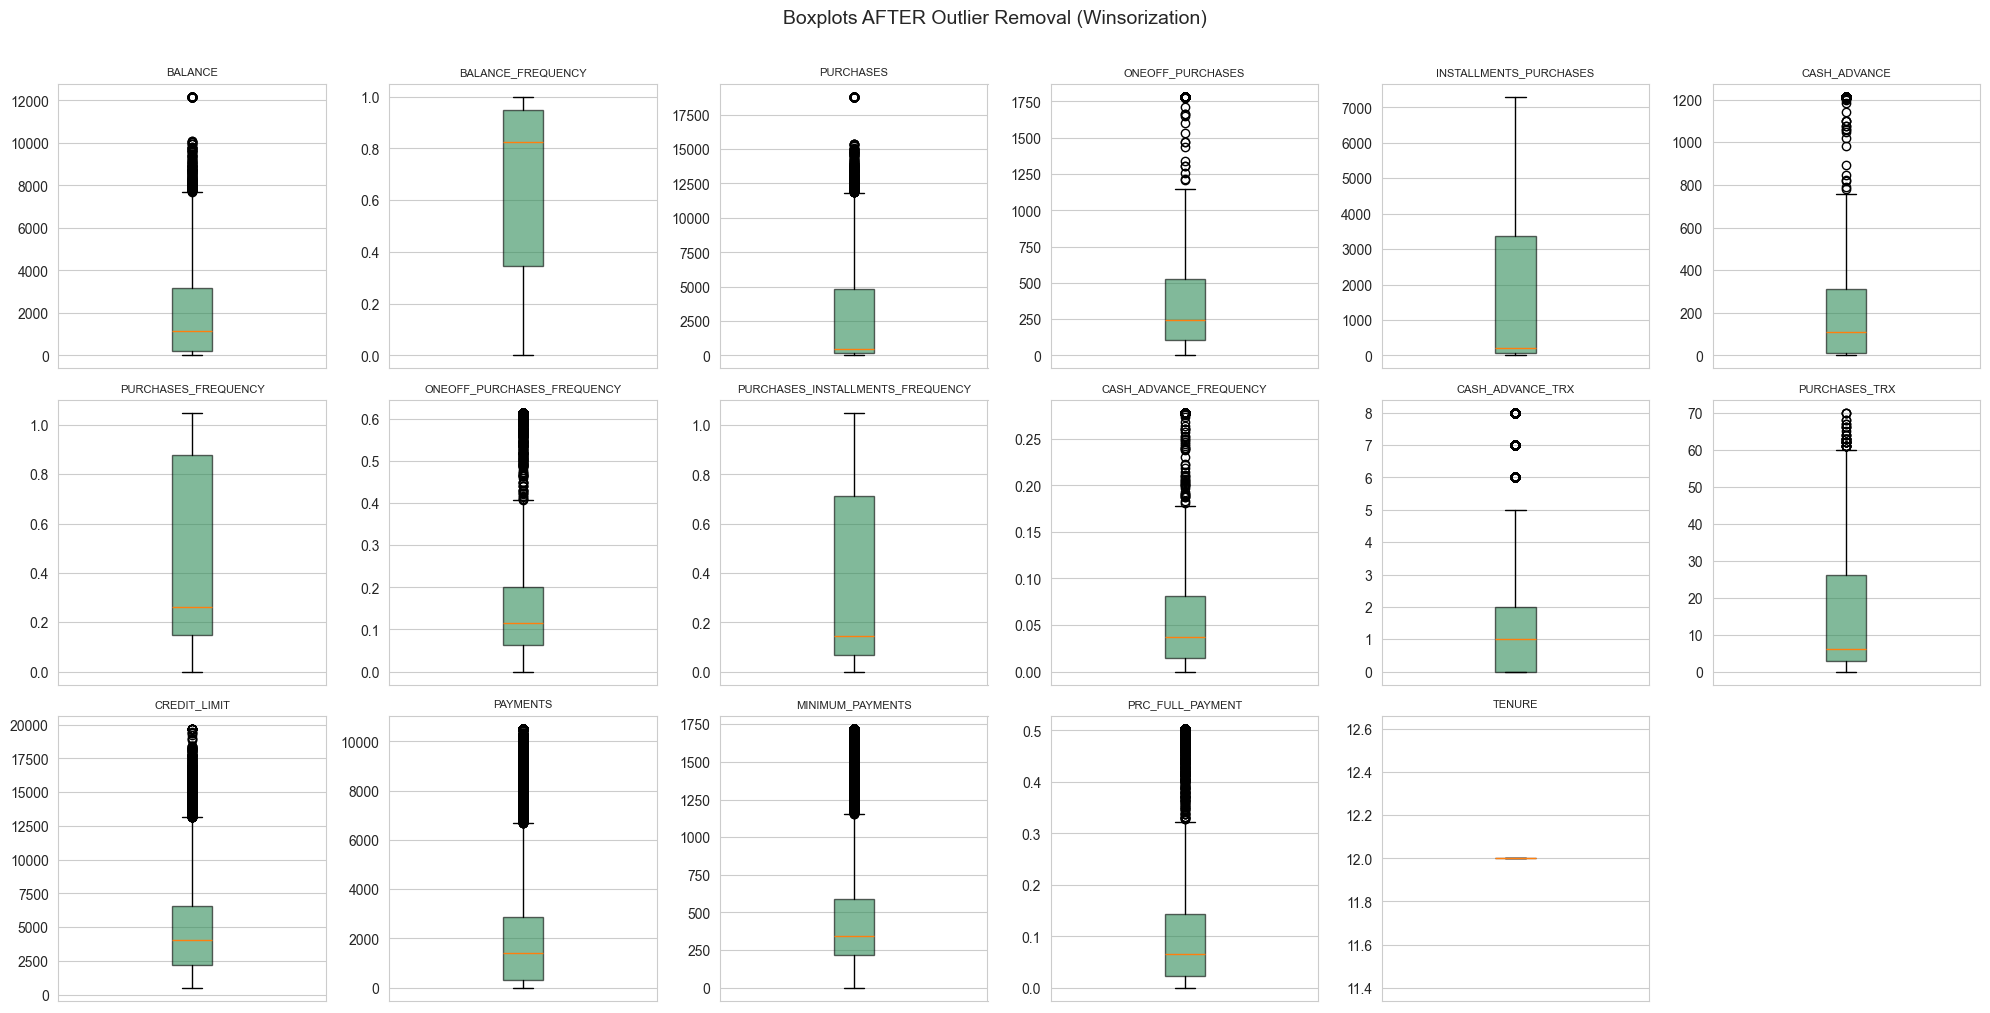

In [104]:
fig, axes = plt.subplots(3, 6, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_clean[col], patch_artist=True,
                    boxprops=dict(facecolor='seagreen', alpha=0.6))
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xticks([])
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplots AFTER Outlier Removal (Winsorization)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Feature Scaling

We apply **StandardScaler** to normalize all features to mean=0 and std=1. This is essential before any distance-based algorithm (K-Means, DBSCAN, SOM) to prevent features with large magnitudes from dominating.

In [105]:
features = df_clean.drop(columns=['CUST_ID'])

scaler = StandardScaler()
scaled_array = scaler.fit_transform(features)

df_scaled = pd.DataFrame(scaled_array, columns=features.columns)

print('Scaling done using StandardScaler')
print('   Mean ≈ 0 and Std ≈ 1 for all features')
print('\nSample stats after scaling:')
df_scaled[features.columns[:5]].describe().loc[['mean','std']].round(3)

Scaling done using StandardScaler
   Mean ≈ 0 and Std ≈ 1 for all features

Sample stats after scaling:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES
mean,0.00,-0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00


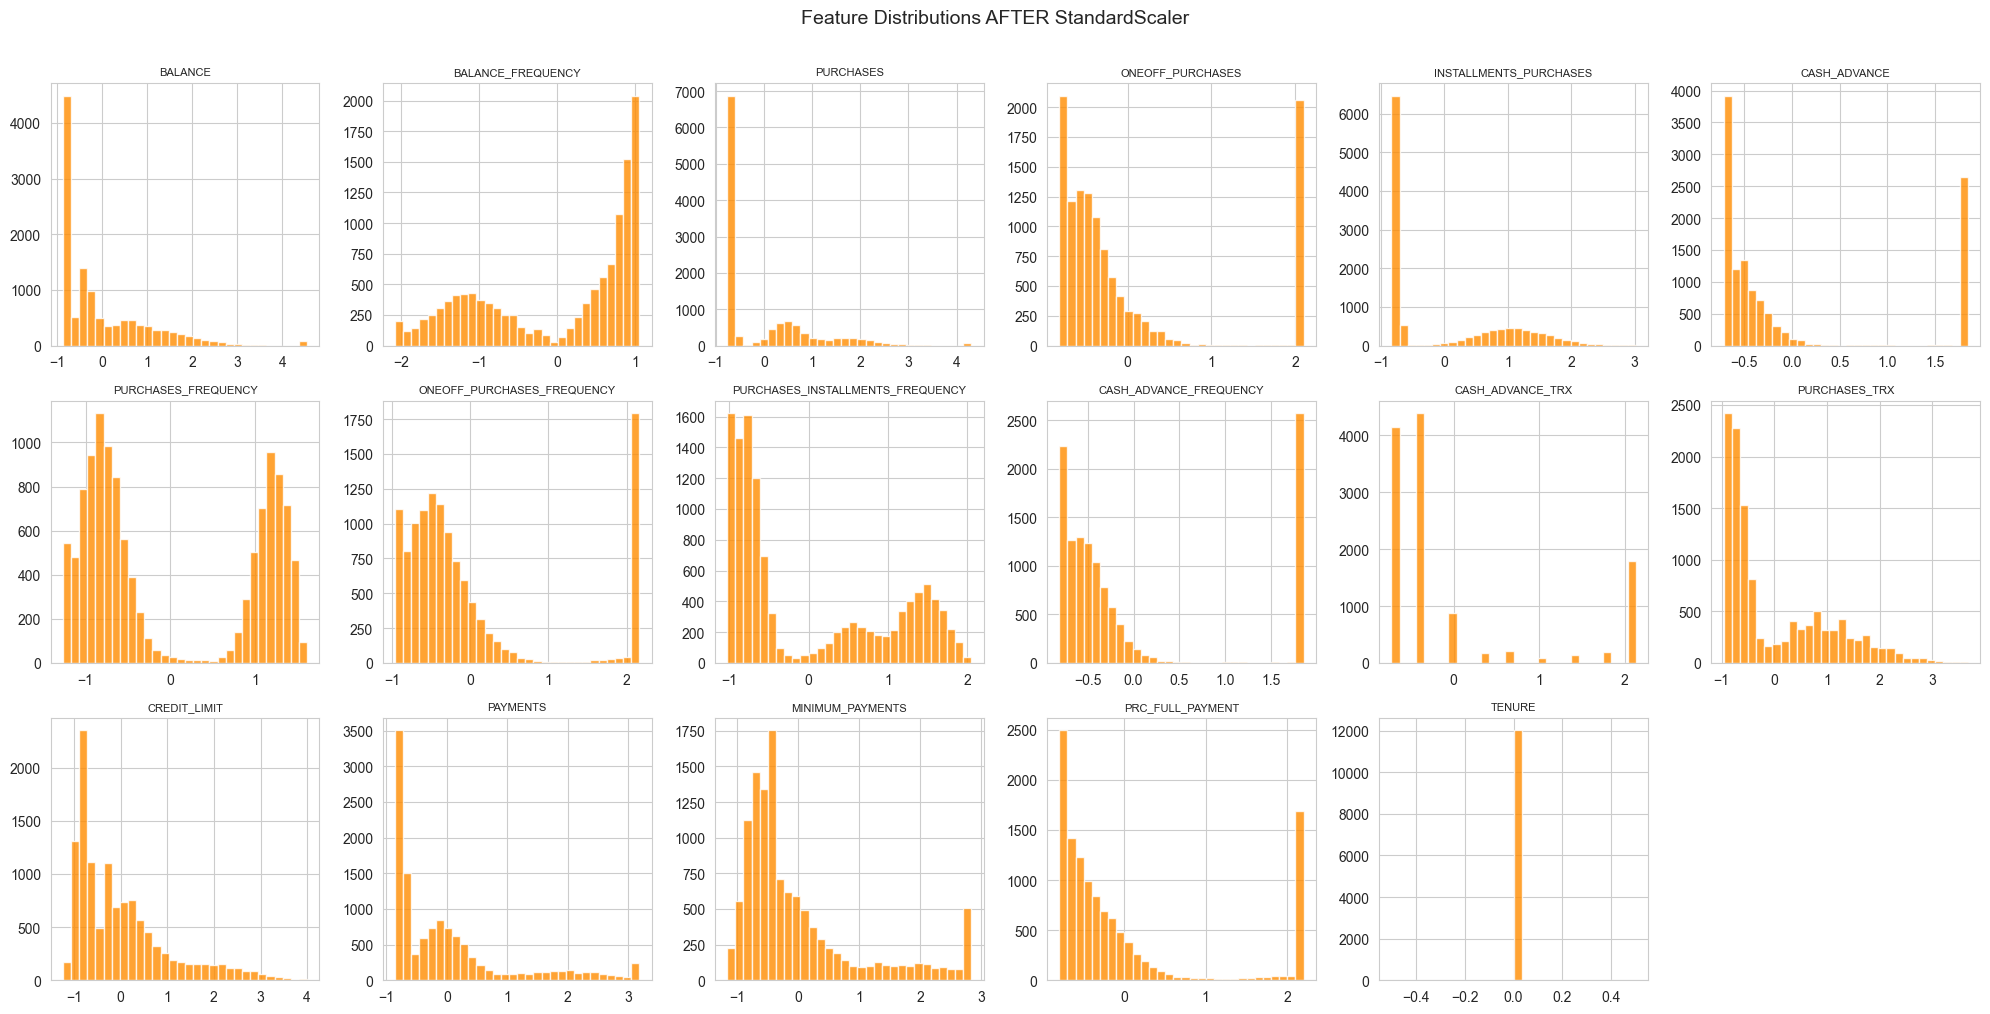

In [106]:
fig, axes = plt.subplots(3, 6, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(features.columns):
    axes[i].hist(df_scaled[col], bins=30, color='darkorange', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=8)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Feature Distributions AFTER StandardScaler', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## PCA Visualization

Reduce the scaled features to 2 principal components for visualization purposes. Note: PCA here is used only for plotting — clustering is done on the full feature space.

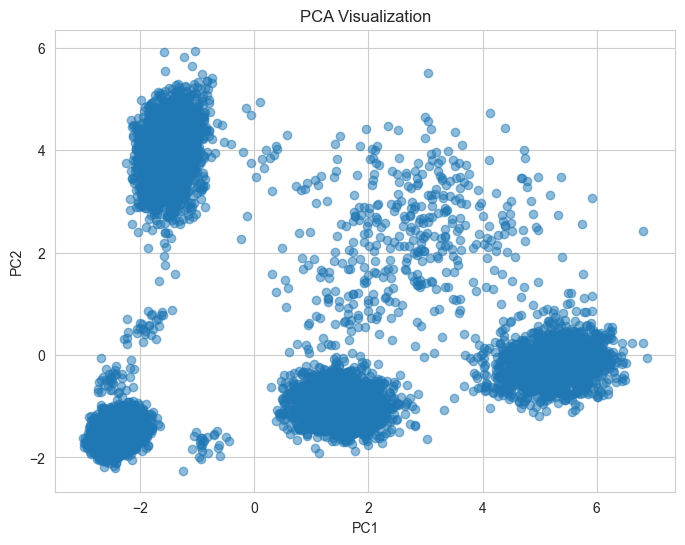

In [107]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_array)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)
plt.title('PCA Visualization')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

## K-Means Clustering

K-Means partitions data into **k spherical clusters** by minimizing within-cluster sum of squares (inertia). We select the optimal k using two methods:
- **Elbow Method**: look for the "elbow" in the inertia curve
- **Silhouette Score**: measures how similar each point is to its own cluster vs. others (higher = better)

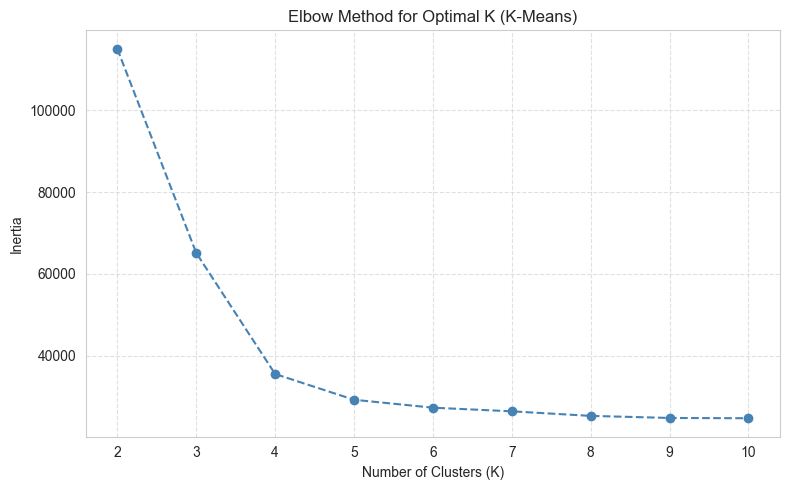

Interpretation: Look for the 'elbow' point where the decrease in inertia starts to level off. This suggests an optimal K.


In [108]:
inertia_values = []
n_range = range(2, 11)

for n in n_range:
    kmeans = KMeans(n_clusters=n, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(scaled_array)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(n_range, inertia_values, marker='o', linestyle='--', color='steelblue')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K (K-Means)')
plt.xticks(n_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Based on the plot, identify the 'elbow' point
# (Often where the rate of decrease in inertia significantly slows down)
# For demonstration, let's pick a plausible elbow point (e.g., K=4 or K=5 from typical results)
# User would interpret this visually. For now, I'll print a note.
print("Interpretation: Look for the 'elbow' point where the decrease in inertia starts to level off. This suggests an optimal K.")

K= 2 | Silhouette: 0.4348
K= 3 | Silhouette: 0.5621
K= 4 | Silhouette: 0.6292
K= 5 | Silhouette: 0.6463
K= 6 | Silhouette: 0.5770
K= 7 | Silhouette: 0.5151
K= 8 | Silhouette: 0.5203
K= 9 | Silhouette: 0.5196
K=10 | Silhouette: 0.2685

 Best K by Silhouette for K-Means: 5


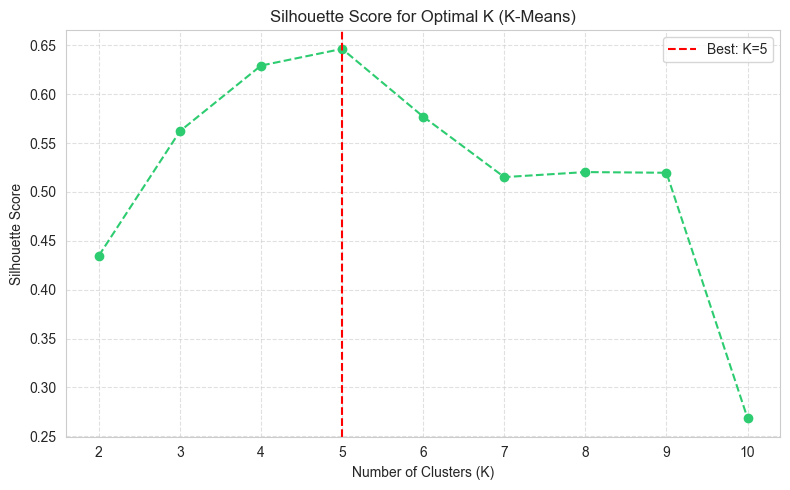

In [109]:
silhouette_scores_kmeans = []
n_range = range(2, 11) # Same range as for Elbow method

for n in n_range:
    kmeans = KMeans(n_clusters=n, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(scaled_array)
    labels_kmeans = kmeans.predict(scaled_array)
    sil_kmeans = silhouette_score(scaled_array, labels_kmeans, sample_size=3000, random_state=42)
    silhouette_scores_kmeans.append(sil_kmeans)
    print(f"K={n:2d} | Silhouette: {sil_kmeans:.4f}")

optimal_n_kmeans_sil = list(n_range)[np.argmax(silhouette_scores_kmeans)]
print(f"\n Best K by Silhouette for K-Means: {optimal_n_kmeans_sil}")

plt.figure(figsize=(8, 5))
plt.plot(n_range, silhouette_scores_kmeans, marker='o', linestyle='--', color='#2ecc71')
plt.axvline(optimal_n_kmeans_sil, color='red', linestyle='--', label=f'Best: K={optimal_n_kmeans_sil}')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal K (K-Means)')
plt.xticks(n_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [110]:
kmeans_std_final = KMeans(n_clusters=optimal_n_kmeans_sil, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans_std_final.fit(scaled_array)
labels_kmeans_std = kmeans_std_final.predict(scaled_array)

print(f"Standard K-Means clustering completed with {optimal_n_kmeans_sil} clusters.")

Standard K-Means clustering completed with 5 clusters.


In [111]:
# Calculate metrics for Standard K-Means
sil_kmeans_std = silhouette_score(scaled_array, labels_kmeans_std, sample_size=3000, random_state=42)
db_score_kmeans_std = davies_bouldin_score(scaled_array, labels_kmeans_std)
ch_score_kmeans_std = calinski_harabasz_score(scaled_array, labels_kmeans_std)

print(f"\nK-Means Standard Metrics (K={optimal_n_kmeans_sil}):")
print(f"  Silhouette Score: {sil_kmeans_std:.4f}")
print(f"  Davies-Bouldin Index: {db_score_kmeans_std:.4f}")
print(f"  Calinski-Harabasz Index: {ch_score_kmeans_std:.4f}")


K-Means Standard Metrics (K=5):
  Silhouette Score: 0.6463
  Davies-Bouldin Index: 1.0058
  Calinski-Harabasz Index: 16742.3582


In [112]:
# Calculate overall means for business interpretation reference
key_features_for_overall_mean = [
    'BALANCE','PURCHASES','CASH_ADVANCE','PAYMENTS',
    'CREDIT_LIMIT','PRC_FULL_PAYMENT','PURCHASES_FREQUENCY'
]
# Use the original df which has the log-transformed values that the profiling also uses.
overall_means = df[key_features_for_overall_mean].mean()
print("Overall means for business interpretation (using preprocessed df):")
display(overall_means)

Overall means for business interpretation (using preprocessed df):


BALANCE               2179.30
PURCHASES             3099.50
CASH_ADVANCE          1313.09
PAYMENTS              2252.19
CREDIT_LIMIT          5034.62
PRC_FULL_PAYMENT         0.16
PURCHASES_FREQUENCY      0.46
dtype: float64

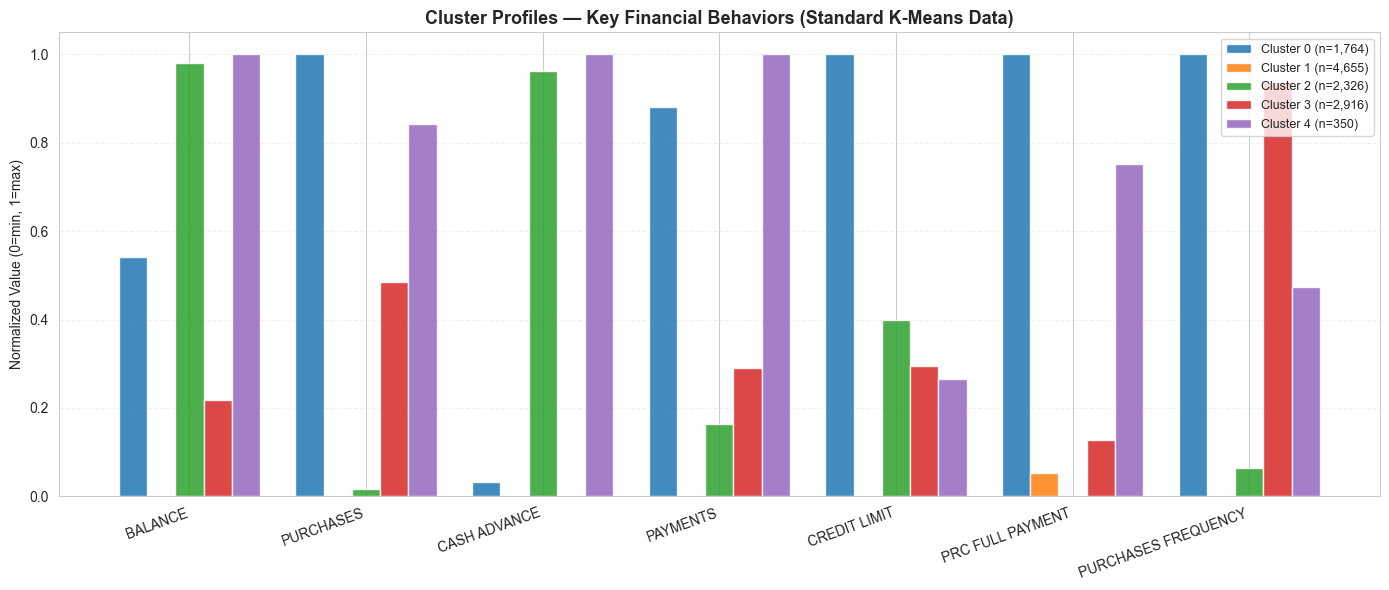

In [113]:
df_result_kmeans_std = df.copy()
df_result_kmeans_std['Cluster_Standard_KMeans'] = labels_kmeans_std

profile_plot_kmeans_std = df_result_kmeans_std.groupby('Cluster_Standard_KMeans')[key_features_for_overall_mean].mean()

# Normalize for visualization
profile_norm_kmeans_std = (profile_plot_kmeans_std - profile_plot_kmeans_std.min()) / (profile_plot_kmeans_std.max() - profile_plot_kmeans_std.min())

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(key_features_for_overall_mean))
width = 0.8 / optimal_n_kmeans_sil

colors_kmeans_std_plot = [f'C{i}' for i in range(optimal_n_kmeans_sil)]

for k in range(optimal_n_kmeans_sil):
    ax.bar(x + k*width, profile_norm_kmeans_std.iloc[k], width,
           label=f'Cluster {k} (n={(labels_kmeans_std==k).sum():,})',
           color=colors_kmeans_std_plot[k], alpha=0.85)

ax.set_xticks(x + width*(optimal_n_kmeans_sil-1)/2)
ax.set_xticklabels([f.replace('_',' ') for f in key_features_for_overall_mean], rotation=20, ha='right')
ax.set_ylabel('Normalized Value (0=min, 1=max)')
ax.set_title('Cluster Profiles — Key Financial Behaviors (Standard K-Means Data)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout(); plt.show()

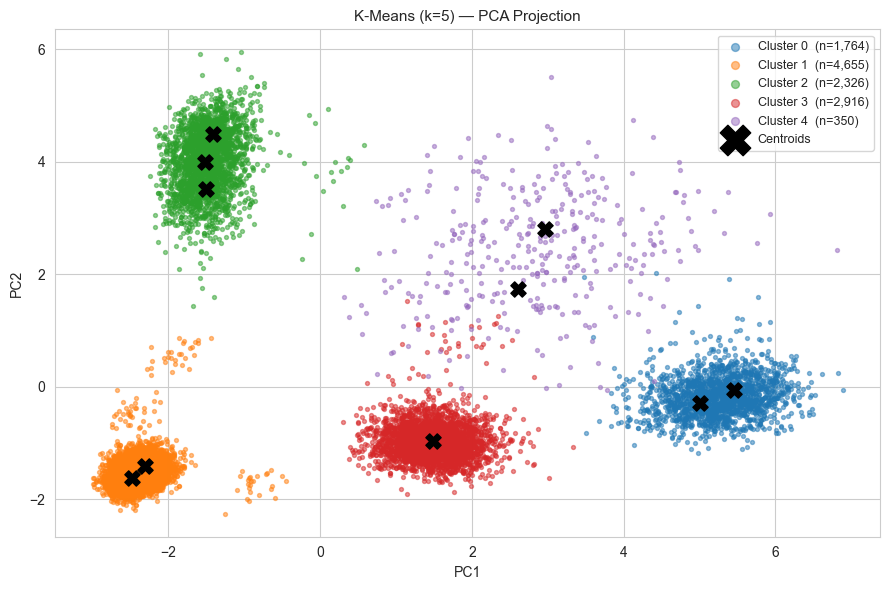

In [114]:
# PCA Visualization — K-Means Clusters
palette = plt.cm.tab10

plt.figure(figsize=(9, 6))
for lbl in sorted(set(labels)):
    mask = labels == lbl
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=[palette(lbl % 10)], s=8, alpha=0.5,
                label=f'Cluster {lbl}  (n={mask.sum():,})')

centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='black', s=120, marker='X', zorder=5, label='Centroids')

plt.title(f'K-Means (k={K}) — PCA Projection', fontsize=11)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()

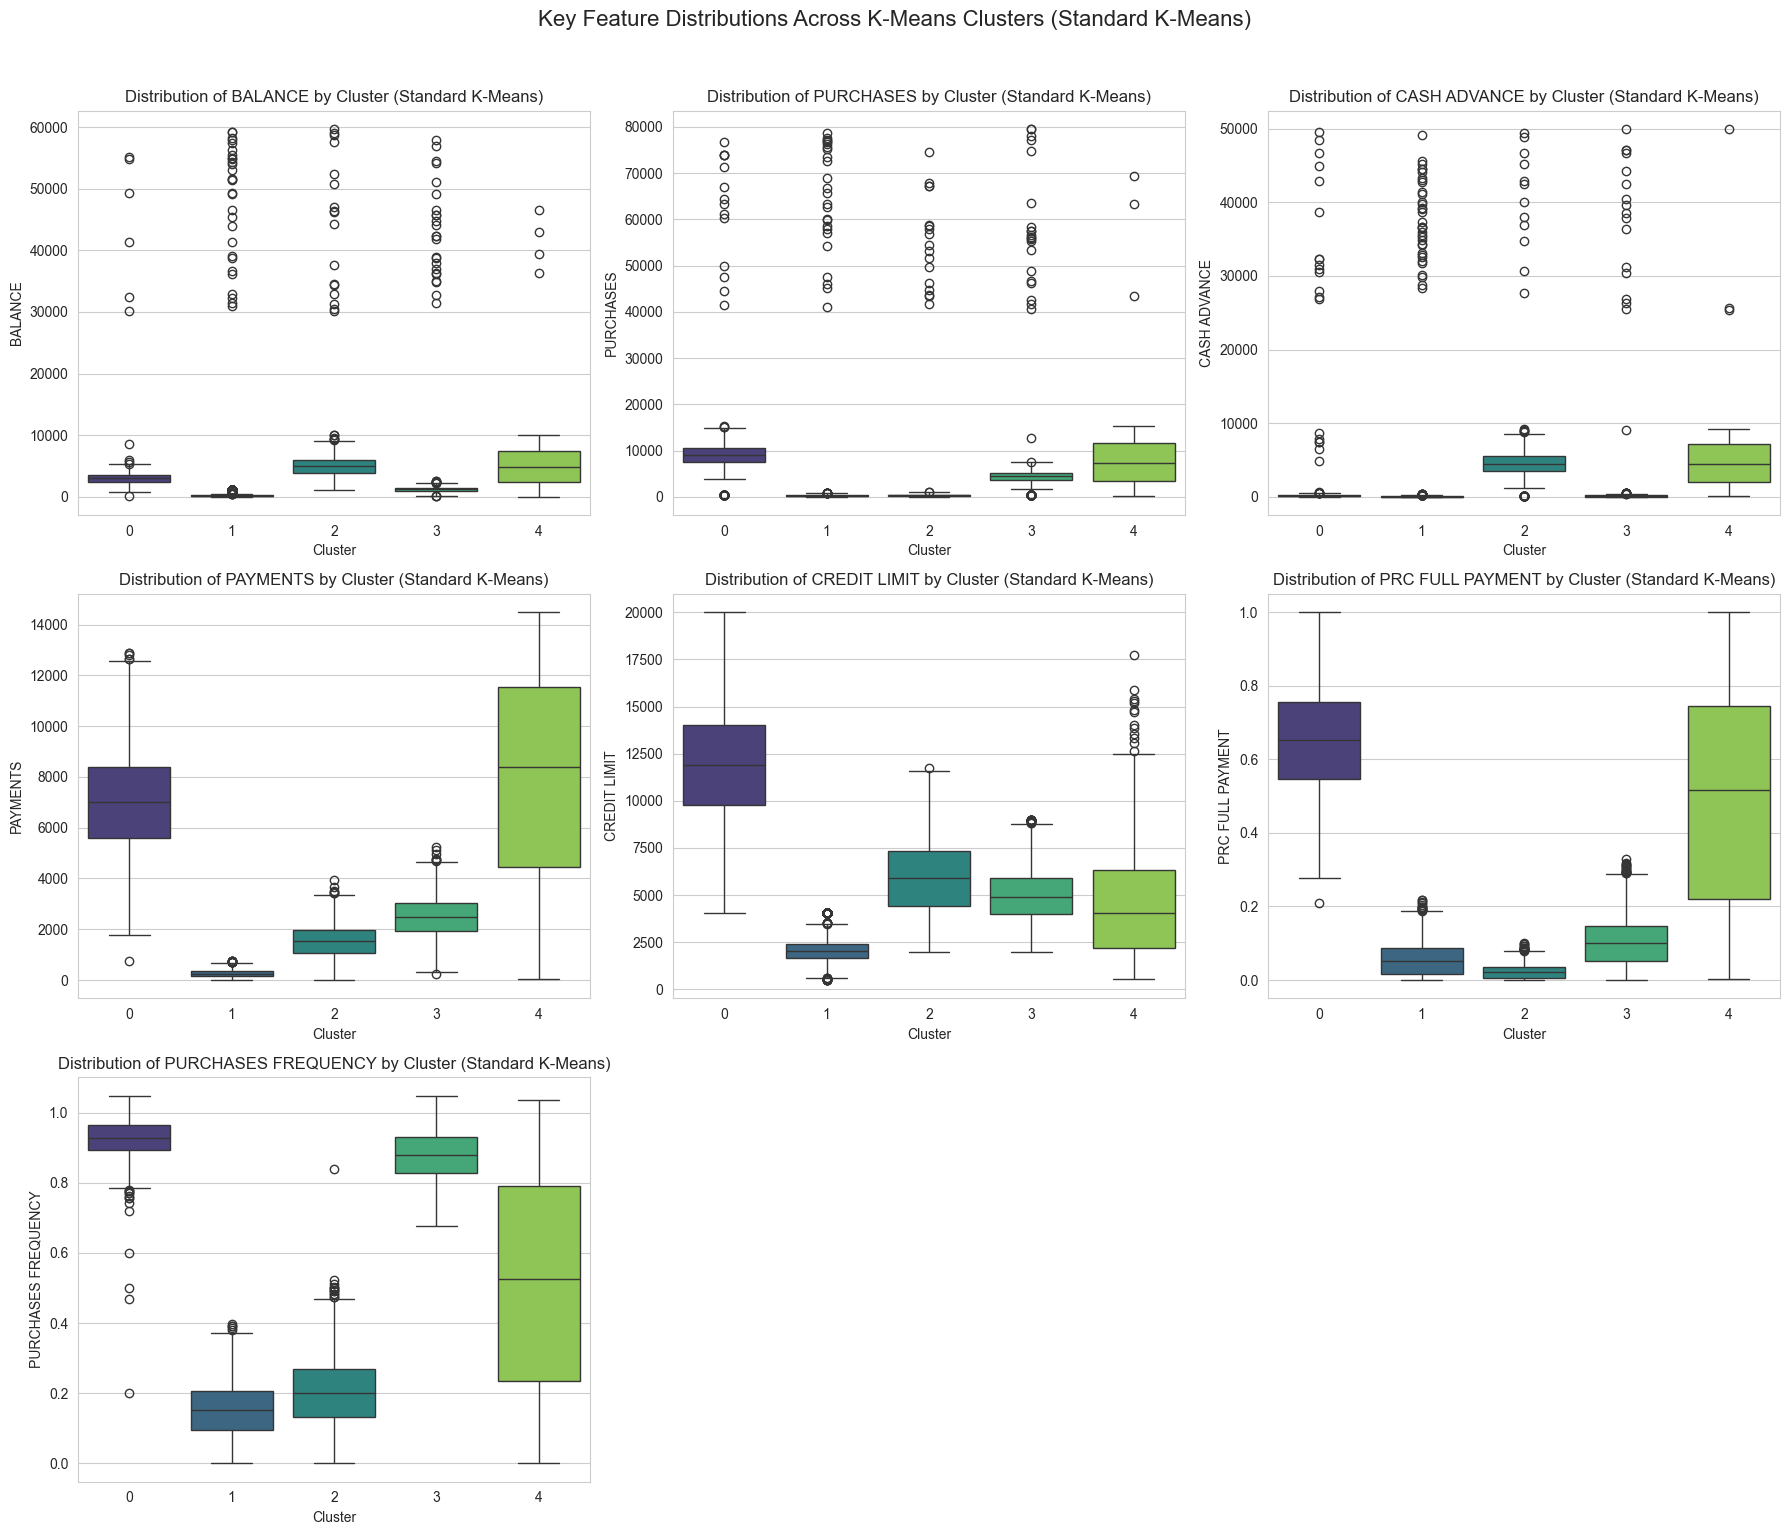

In [115]:
import seaborn as sns
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

selected_features = [
    'BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'PAYMENTS',
    'CREDIT_LIMIT', 'PRC_FULL_PAYMENT', 'PURCHASES_FREQUENCY'
]

# Use df_result_kmeans_std and Cluster_Standard_KMeans for standard K-Means profiling
for i, feature in enumerate(selected_features):
    if i < len(axes):
        sns.boxplot(x='Cluster_Standard_KMeans', y=feature, data=df_result_kmeans_std, ax=axes[i], palette='viridis')
        axes[i].set_title(f'Distribution of {feature.replace("_", " ")} by Cluster (Standard K-Means)')
        axes[i].set_xlabel('Cluster')
        axes[i].set_ylabel(feature.replace("_", " "))

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Key Feature Distributions Across K-Means Clusters (Standard K-Means)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [116]:
results_comparison = pd.DataFrame({
    'method': [
        'K-Means (Standard)'

    ],
    'Optimal K': [
        optimal_n_kmeans_sil

    ],
    'Silhouette': [
        sil_kmeans_std

    ],
    'Davies-Bouldin': [
        db_score_kmeans_std

    ],
    'Calinski-Harabasz': [
        ch_score_kmeans_std

    ]
})

print('\n=== Comprehensive Clustering Metrics Comparison ===')
print(results_comparison.to_string(index=False))

print('\n**Interpretation Guidelines:**')
print('- **Silhouette Score**: Higher is better (range -1 to 1). Indicates how well-separated clusters are.')
print('- **Davies-Bouldin Index**: Lower is better. Measures the average similarity ratio of each cluster with its most similar cluster. Lower values indicate better partitioning.')
print('- **Calinski-Harabasz Index**: Higher is better. Measures the ratio of the sum of between-clusters dispersion to within-cluster dispersion.')


=== Comprehensive Clustering Metrics Comparison ===
            method  Optimal K  Silhouette  Davies-Bouldin  Calinski-Harabasz
K-Means (Standard)          5        0.65            1.01           16742.36

**Interpretation Guidelines:**
- **Silhouette Score**: Higher is better (range -1 to 1). Indicates how well-separated clusters are.
- **Davies-Bouldin Index**: Lower is better. Measures the average similarity ratio of each cluster with its most similar cluster. Lower values indicate better partitioning.
- **Calinski-Harabasz Index**: Higher is better. Measures the ratio of the sum of between-clusters dispersion to within-cluster dispersion.


In [117]:
# Cluster Profiles
df_profile = df_clean.drop(columns=['CUST_ID']).copy()
df_profile['Cluster'] = labels

profile = df_profile.groupby('Cluster').mean().round(2)
print('Cluster profiles (mean of original features):')
profile

Cluster profiles (mean of original features):


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,2991.51,0.96,8871.04,1782.81,3025.24,172.42,0.93,0.61,0.55,0.03,0.54,40.05,11764.79,6961.45,483.28,0.49,12.00
1,259.58,0.30,324.02,133.38,92.84,57.85,0.15,0.08,0.07,0.02,0.53,3.05,2100.07,256.58,209.60,0.06,12.00
2,4982.14,0.95,454.16,203.92,117.70,1193.21,0.20,0.10,0.10,0.28,7.36,5.16,5948.94,1513.59,1101.71,0.02,12.00
3,1279.15,0.85,4480.02,402.05,4027.49,120.35,0.88,0.15,0.85,0.04,1.07,25.07,4960.76,2478.34,398.85,0.10,12.00
4,4982.12,0.55,7519.98,1629.85,3634.28,1109.76,0.52,0.44,0.53,0.23,2.25,13.27,4675.88,7218.52,1243.05,0.37,12.00


In [118]:
# Cluster Naming Function — used for all algorithms
def auto_name_clusters(profile_df):
    names = {}
    used  = set()

    ranks = {}
    for cluster_id in profile_df.index:
        ranks[cluster_id] = {}
        for feat in profile_df.columns:
            col_vals = profile_df[feat]
            ranks[cluster_id][feat] = col_vals.rank(pct=True)[cluster_id]

    rules = [
        ('Cash Advance Heavy',  lambda r: r.get('CASH_ADVANCE',0) >= 0.75 and r.get('CASH_ADVANCE_FREQUENCY',0) >= 0.6),
        ('Premium Spender',     lambda r: r.get('PURCHASES',0) >= 0.75 and r.get('PRC_FULL_PAYMENT',0) >= 0.6),
        ('Active Shopper',      lambda r: r.get('PURCHASES',0) >= 0.75 and r.get('PURCHASES_FREQUENCY',0) >= 0.6),
        ('Installment Buyer',   lambda r: r.get('INSTALLMENTS_PURCHASES',0) >= 0.7 and r.get('PURCHASES_INSTALLMENTS_FREQUENCY',0) >= 0.6),
        ('High Credit Limit',   lambda r: r.get('CREDIT_LIMIT',0) >= 0.75 and r.get('BALANCE',0) >= 0.5),
        ('Transactor',          lambda r: r.get('PRC_FULL_PAYMENT',0) >= 0.75 and r.get('PURCHASES',0) >= 0.5),
        ('Revolver',            lambda r: r.get('BALANCE',0) >= 0.7 and r.get('PRC_FULL_PAYMENT',0) <= 0.35),
        ('Low Activity',        lambda r: r.get('PURCHASES',0) <= 0.3 and r.get('CASH_ADVANCE',0) <= 0.3 and r.get('BALANCE',0) <= 0.4),
        ('Moderate User',       lambda r: 0.35 <= r.get('PURCHASES',0) <= 0.65),
    ]

    for cluster_id in profile_df.index:
        r = ranks[cluster_id]
        assigned = False
        for name, condition in rules:
            if name not in used and condition(r):
                names[cluster_id] = name
                used.add(name)
                assigned = True
                break
        if not assigned:
            top_feat = max(r, key=r.get)
            feat_label = {
                'BALANCE'          : 'High Balance',
                'PURCHASES'        : 'Moderate Spender',
                'CASH_ADVANCE'     : 'Occasional Cash User',
                'CREDIT_LIMIT'     : 'Mid Credit',
                'PAYMENTS'         : 'Regular Payer',
                'MINIMUM_PAYMENTS' : 'Minimum Payer',
            }
            names[cluster_id] = feat_label.get(top_feat, f'Segment {cluster_id}')

    return names

print('✅ auto_name_clusters function defined')

✅ auto_name_clusters function defined


In [119]:
# K-Means Cluster Naming
kmeans_cluster_names = auto_name_clusters(profile)

print('K-Means Cluster Names:')
for k, v in kmeans_cluster_names.items():
    print(f'  Cluster {k} -> {v}')

df_clean['KMeans_Cluster_ID']   = labels
df_clean['KMeans_Cluster_Name'] = [kmeans_cluster_names[l] for l in labels]

print(f'\nDistribution:')
print(df_clean['KMeans_Cluster_Name'].value_counts())

K-Means Cluster Names:
  Cluster 0 -> Premium Spender
  Cluster 1 -> Low Activity
  Cluster 2 -> Cash Advance Heavy
  Cluster 3 -> Installment Buyer
  Cluster 4 -> Active Shopper

Distribution:
KMeans_Cluster_Name
Low Activity          4655
Installment Buyer     2916
Cash Advance Heavy    2326
Premium Spender       1764
Active Shopper         350
Name: count, dtype: int64


## Autoencoder + K-Means

A **neural network autoencoder** learns a compressed (8-dimensional) representation of the 17-feature input by reconstructing it through a bottleneck. The encoded features capture non-linear relationships that standard scaling cannot — feeding these into K-Means often reveals tighter, more meaningful clusters.

**Architecture:** Input(17) → 16 → **8** → 16 → Output(17)  
**Loss:** MSE (reconstruction error) | **Optimizer:** Adam

🚀 Training Autoencoder...


Epoch [10/50] Loss: 0.072306
Epoch [20/50] Loss: 0.053519
Epoch [30/50] Loss: 0.044999
Epoch [40/50] Loss: 0.039950
Epoch [50/50] Loss: 0.036706


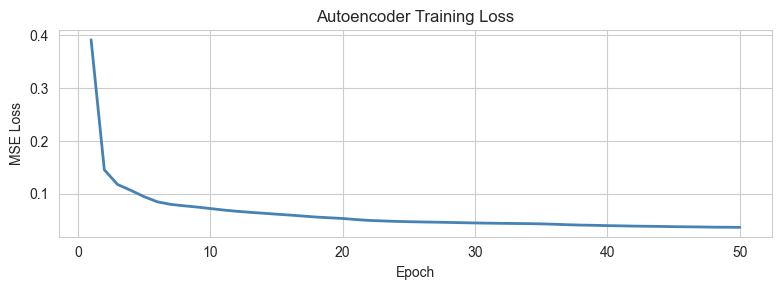

In [120]:
# Autoencoder Definition & Training
X = torch.tensor(df_scaled.values, dtype=torch.float32)
dataset = TensorDataset(X)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

input_dim    = X.shape[1]
encoding_dim = 8

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, encoding_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

model     = Autoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs     = 50
loss_curve = []
print('🚀 Training Autoencoder...')
for epoch in range(epochs):
    total_loss = 0
    for batch in loader:
        x_batch = batch[0]
        loss = criterion(model(x_batch), x_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    loss_curve.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.6f}')

# Learning curve
plt.figure(figsize=(8, 3))
plt.plot(range(1, epochs+1), loss_curve, color='steelblue', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training Loss')
plt.tight_layout()
plt.show()

In [121]:
# Extract encoded features
model.eval()
with torch.no_grad():
    encoded_features = model.encoder(X).numpy()

df_encoded = pd.DataFrame(encoded_features, columns=[f'AE_{i}' for i in range(encoding_dim)])
print('✅ Encoded Features Shape:', df_encoded.shape)
print(df_encoded.head())

✅ Encoded Features Shape: (12011, 8)
   AE_0  AE_1  AE_2  AE_3  AE_4  AE_5  AE_6  AE_7
0  2.10  1.99  0.94  1.73  1.56  1.32  1.56  5.40
1  3.53  3.72  1.10  3.29  4.77  3.15  3.80  9.64
2  2.48  2.83  2.29  3.36  4.92  2.10  3.44  8.48
3  4.77  0.67  0.79  2.93  1.15  0.57  2.60  0.54
4  5.61  1.72  0.39  3.82  1.16  0.43  3.43  0.86


### K-Means on Autoencoder Features

Now we run K-Means on the 8-dimensional encoded representation instead of the raw 17 features. This often produces better-separated clusters because the autoencoder has already removed noise and compressed correlated features.

In [122]:
# K-Means on Autoencoder features — k selection
inertia_list_ae    = []
silhouette_list_ae = []
k_values_ae        = range(2, 11)

print('=' * 60)
print('K-Means on Autoencoder Features')
print('=' * 60)

for k in k_values_ae:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_ae = km.fit_predict(df_encoded)
    inertia_list_ae.append(km.inertia_)
    sil_score = silhouette_score(df_encoded, labels_ae)
    silhouette_list_ae.append(sil_score)
    print(f'K = {k} -> Inertia: {km.inertia_:.2f}, Silhouette: {sil_score:.4f}')

best_k_ae = k_values_ae[np.argmax(silhouette_list_ae)]
print('=' * 60)
print(f'✅ Best K for Autoencoder Features = {best_k_ae}')
print('=' * 60)

K-Means on Autoencoder Features
K = 2 -> Inertia: 195298.92, Silhouette: 0.4832
K = 3 -> Inertia: 96617.10, Silhouette: 0.6314
K = 4 -> Inertia: 44271.98, Silhouette: 0.7079
K = 5 -> Inertia: 32607.77, Silhouette: 0.7195
K = 6 -> Inertia: 29416.83, Silhouette: 0.6507
K = 7 -> Inertia: 26672.80, Silhouette: 0.5536
K = 8 -> Inertia: 24122.27, Silhouette: 0.5109
K = 9 -> Inertia: 22564.78, Silhouette: 0.5134
K = 10 -> Inertia: 21421.04, Silhouette: 0.5006
✅ Best K for Autoencoder Features = 5


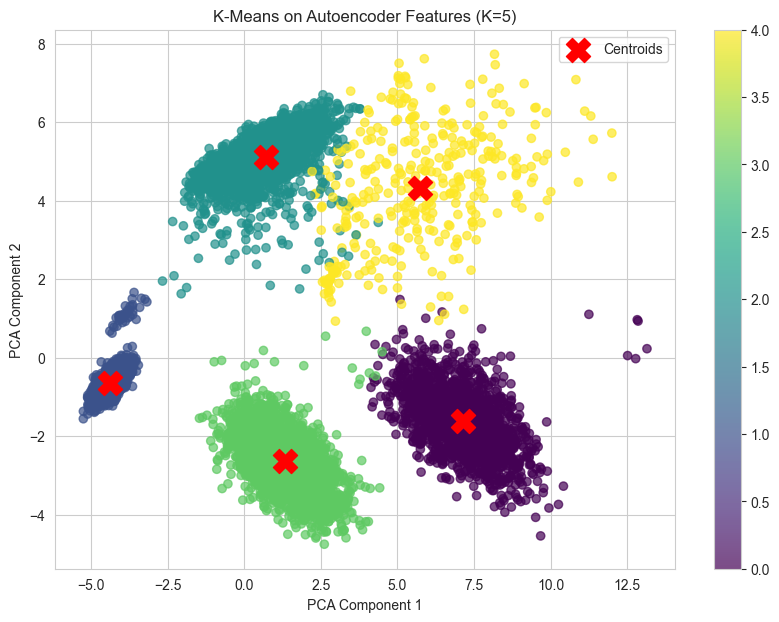

In [123]:
# Final AE K-Means + PCA Visualization
final_kmeans_ae  = KMeans(n_clusters=best_k_ae, random_state=42, n_init=10)
final_labels_ae  = final_kmeans_ae.fit_predict(df_encoded)

pca_ae         = PCA(n_components=2)
pca_result_ae  = pca_ae.fit_transform(df_encoded)
centroids_2d_ae = pca_ae.transform(final_kmeans_ae.cluster_centers_)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(pca_result_ae[:, 0], pca_result_ae[:, 1],
                      c=final_labels_ae, cmap='viridis', alpha=0.7)
plt.scatter(centroids_2d_ae[:, 0], centroids_2d_ae[:, 1],
            marker='X', s=300, c='red', label='Centroids')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'K-Means on Autoencoder Features (K={best_k_ae})')
plt.legend()
plt.colorbar(scatter)
plt.show()

In [124]:
# AE K-Means Cluster Naming
profile_ae_orig = df_clean.drop(columns=['CUST_ID','KMeans_Cluster_ID','KMeans_Cluster_Name'], errors='ignore').copy()
profile_ae_orig['Cluster'] = final_labels_ae
profile_ae_means = profile_ae_orig.groupby('Cluster').mean()

ae_cluster_names = auto_name_clusters(profile_ae_means)

print('Autoencoder K-Means Cluster Names:')
for k, v in ae_cluster_names.items():
    print(f'  Cluster {k} -> {v}')

df_clean['AE_Cluster_ID']   = final_labels_ae
df_clean['AE_Cluster_Name'] = [ae_cluster_names[l] for l in final_labels_ae]

print(f'\nDistribution:')
print(df_clean['AE_Cluster_Name'].value_counts())

Autoencoder K-Means Cluster Names:
  Cluster 0 -> Premium Spender
  Cluster 1 -> Low Activity
  Cluster 2 -> Cash Advance Heavy
  Cluster 3 -> Installment Buyer
  Cluster 4 -> Active Shopper

Distribution:
AE_Cluster_Name
Low Activity          4626
Installment Buyer     2899
Cash Advance Heavy    2355
Premium Spender       1775
Active Shopper         356
Name: count, dtype: int64


## DBSCAN Clustering

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) groups points that are closely packed and marks low-density points as **noise (-1)**. Unlike K-Means, it:
- Does **not** require specifying k upfront
- Can find **arbitrary-shaped** clusters
- Naturally handles outliers as noise

**Key parameters:**
- `eps`: neighborhood radius
- `min_samples`: minimum points to form a dense region

We tune `eps` using the **K-distance graph** (elbow point) and validate with a composite Silhouette × coverage score.

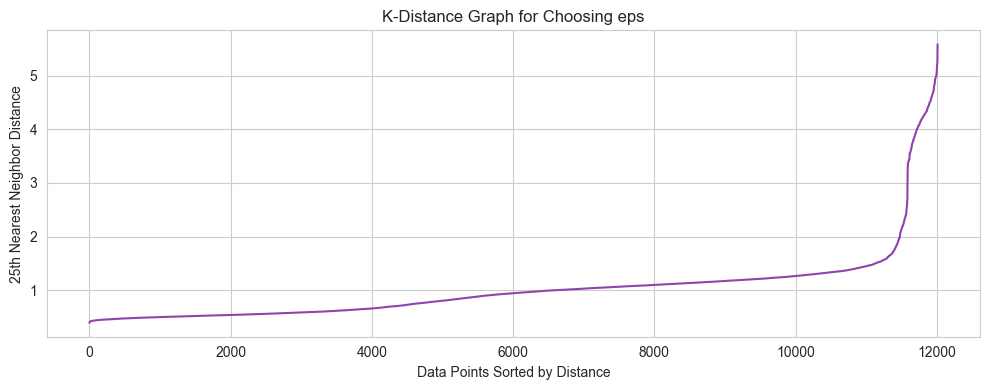

In [125]:
# K-distance graph to choose best eps
k_neighbors = 25
neighbors   = NearestNeighbors(n_neighbors=k_neighbors).fit(scaled_array)
distances, _ = neighbors.kneighbors(scaled_array)
k_distances  = np.sort(distances[:, k_neighbors-1])

plt.figure(figsize=(10, 4))
plt.plot(k_distances, color='#8e44ad', linewidth=1.5)
plt.xlabel('Data Points Sorted by Distance')
plt.ylabel(f'{k_neighbors}th Nearest Neighbor Distance')
plt.title('K-Distance Graph for Choosing eps')
plt.tight_layout()
plt.grid(True)
plt.show()

 eps  n_clusters  noise_%  score
1.00           5    24.00   0.47
1.10           5    13.10   0.53
1.20           6     7.70   0.56
1.30           7     5.60   0.57
1.40           7     5.00   0.57
1.50           7     4.80   0.57
1.60           7     4.60   0.57
1.70           7     4.40   0.57
1.80           8     4.00   0.52
1.90           7     3.90   0.59
2.00           7     3.70   0.59
2.10           7     3.60   0.59
2.20           7     3.60   0.59
2.30           7     3.60   0.59
2.40           6     3.50   0.65
2.50           6     3.50   0.65
2.60           6     3.50   0.65
2.70           6     3.50   0.65
2.80           6     3.50   0.65
2.90           6     3.50   0.65
3.00           6     3.50   0.65
3.10           3     3.50   0.19
3.20           4     3.30   0.16
3.30           4     3.00   0.16
3.40           4     2.70   0.16

Best eps: 2.4 (score: 0.6487, clusters: 6)


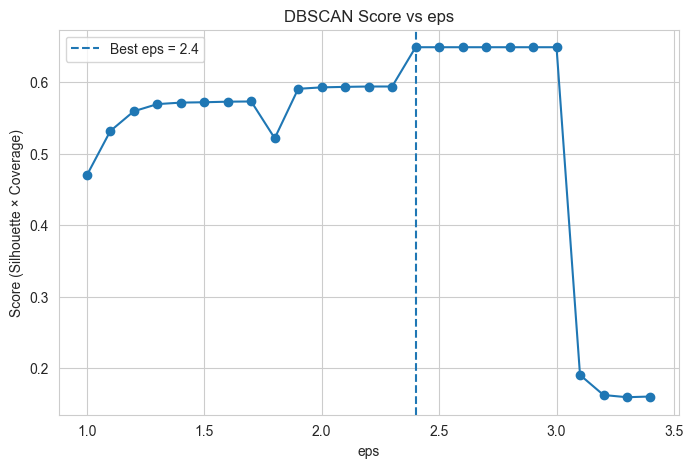

In [126]:
# eps tuning — composite score (Silhouette × coverage)
eps_range  = np.arange(1.0, 3.5, 0.1)
results_db = []

for eps in eps_range:
    db   = DBSCAN(eps=eps, min_samples=25)
    lbls = db.fit_predict(scaled_array)
    mask = lbls != -1
    n_cl = len(set(lbls)) - (1 if -1 in lbls else 0)
    noise_pct = 100 * (lbls == -1).sum() / len(lbls)
    clustered_ratio = sum(mask) / len(lbls)

    if n_cl > 1 and sum(mask) > 1:
        sil   = silhouette_score(scaled_array[mask], lbls[mask])
        score = sil * clustered_ratio
    else:
        score = -1

    results_db.append({'eps': round(eps, 2), 'n_clusters': n_cl,
                       'noise_%': round(noise_pct, 1), 'score': round(score, 4)})

results_db_df = pd.DataFrame(results_db)
print(results_db_df.to_string(index=False))

best_idx   = results_db_df['score'].idxmax()
best_eps   = results_db_df.loc[best_idx, 'eps']
best_score = results_db_df.loc[best_idx, 'score']
best_clusters = results_db_df.loc[best_idx, 'n_clusters']

print(f'\nBest eps: {best_eps} (score: {best_score:.4f}, clusters: {best_clusters})')

plt.figure(figsize=(8, 5))
plt.plot(results_db_df['eps'], results_db_df['score'], marker='o')
plt.axvline(x=best_eps, linestyle='--', label=f'Best eps = {best_eps}')
plt.xlabel('eps')
plt.ylabel('Score (Silhouette × Coverage)')
plt.title('DBSCAN Score vs eps')
plt.legend()
plt.grid(True)
plt.show()

eps=2.40 → Clusters: 6, Noise: 426 (3.5%)
Silhouette Score    : 0.6725
Davies-Bouldin      : 0.4717
Calinski-Harabasz   : 17781.48


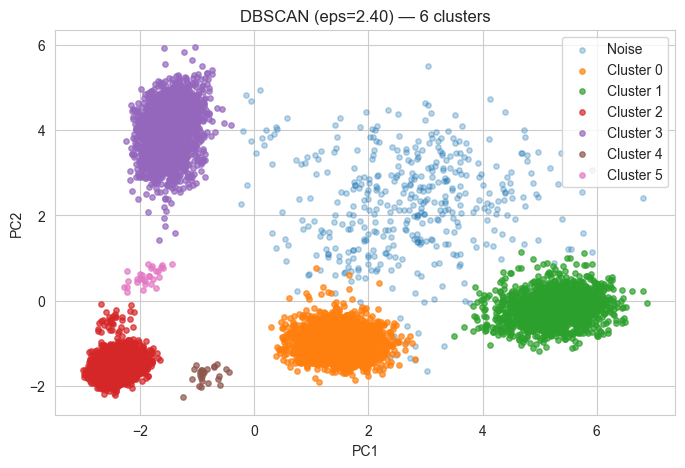

In [127]:
# Final DBSCAN Model
db_final    = DBSCAN(eps=best_eps, min_samples=25).fit(scaled_array)
dbscan_labels = db_final.labels_

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db    = (dbscan_labels == -1).sum()
mask_db       = dbscan_labels != -1

if n_clusters_db > 1 and sum(mask_db) > 1:
    sil_db = silhouette_score(scaled_array[mask_db], dbscan_labels[mask_db])
    dbi_db = davies_bouldin_score(scaled_array[mask_db], dbscan_labels[mask_db])
    ch_db  = calinski_harabasz_score(scaled_array[mask_db], dbscan_labels[mask_db])
else:
    sil_db = dbi_db = ch_db = -1

print(f'eps={best_eps:.2f} → Clusters: {n_clusters_db}, Noise: {n_noise_db} ({100*n_noise_db/len(dbscan_labels):.1f}%)')
print(f'Silhouette Score    : {sil_db:.4f}')
print(f'Davies-Bouldin      : {dbi_db:.4f}')
print(f'Calinski-Harabasz   : {ch_db:.2f}')

pca_db   = PCA(n_components=2, random_state=42)
X_2d     = pca_db.fit_transform(scaled_array)

plt.figure(figsize=(8, 5))
for lbl in sorted(set(dbscan_labels)):
    mask_lbl = dbscan_labels == lbl
    alpha    = 0.3 if lbl == -1 else 0.7
    label_str = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    plt.scatter(X_2d[mask_lbl, 0], X_2d[mask_lbl, 1],
                s=15, alpha=alpha, label=label_str)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'DBSCAN (eps={best_eps:.2f}) — {n_clusters_db} clusters')
plt.legend()
plt.show()

In [128]:
# Cluster size breakdown
unique_db, counts_db = np.unique(dbscan_labels, return_counts=True)
for label, count in zip(unique_db, counts_db):
    tag = 'Noise' if label == -1 else f'Cluster {label}'
    print(f'{tag}: {count:,} points ({100*count/len(dbscan_labels):.1f}%)')

Noise: 426 points (3.5%)
Cluster 0: 2,870 points (23.9%)
Cluster 1: 1,752 points (14.6%)
Cluster 2: 4,601 points (38.3%)
Cluster 3: 2,308 points (19.2%)
Cluster 4: 25 points (0.2%)
Cluster 5: 29 points (0.2%)


### DBSCAN Cluster Naming

We apply `auto_name_clusters` to the non-noise DBSCAN clusters using original feature means, the same way we did for K-Means.

In [129]:
# DBSCAN Cluster Naming (non-noise clusters only)
profile_db_orig = df_clean.drop(
    columns=['CUST_ID','KMeans_Cluster_ID','KMeans_Cluster_Name',
             'AE_Cluster_ID','AE_Cluster_Name'], errors='ignore').copy()
profile_db_orig['Cluster'] = dbscan_labels

# Only named clusters (exclude noise = -1)
profile_db_means = profile_db_orig[profile_db_orig['Cluster'] != -1].groupby('Cluster').mean()

dbscan_cluster_names = auto_name_clusters(profile_db_means)
# Noise gets its own label
dbscan_cluster_names[-1] = 'Noise / Outlier'

print('DBSCAN Cluster Names:')
for k, v in dbscan_cluster_names.items():
    print(f'  Cluster {k} -> {v}')

df_clean['DBSCAN_Cluster_ID']   = dbscan_labels
df_clean['DBSCAN_Cluster_Name'] = [dbscan_cluster_names[l] for l in dbscan_labels]

print(f'\nDistribution:')
print(df_clean['DBSCAN_Cluster_Name'].value_counts())

DBSCAN Cluster Names:
  Cluster 0 -> Installment Buyer
  Cluster 1 -> Cash Advance Heavy
  Cluster 2 -> Segment 2
  Cluster 3 -> High Credit Limit
  Cluster 4 -> Moderate Spender
  Cluster 5 -> High Balance
  Cluster -1 -> Noise / Outlier

Distribution:
DBSCAN_Cluster_Name
Segment 2             4601
Installment Buyer     2870
High Credit Limit     2308
Cash Advance Heavy    1752
Noise / Outlier        426
High Balance            29
Moderate Spender        25
Name: count, dtype: int64


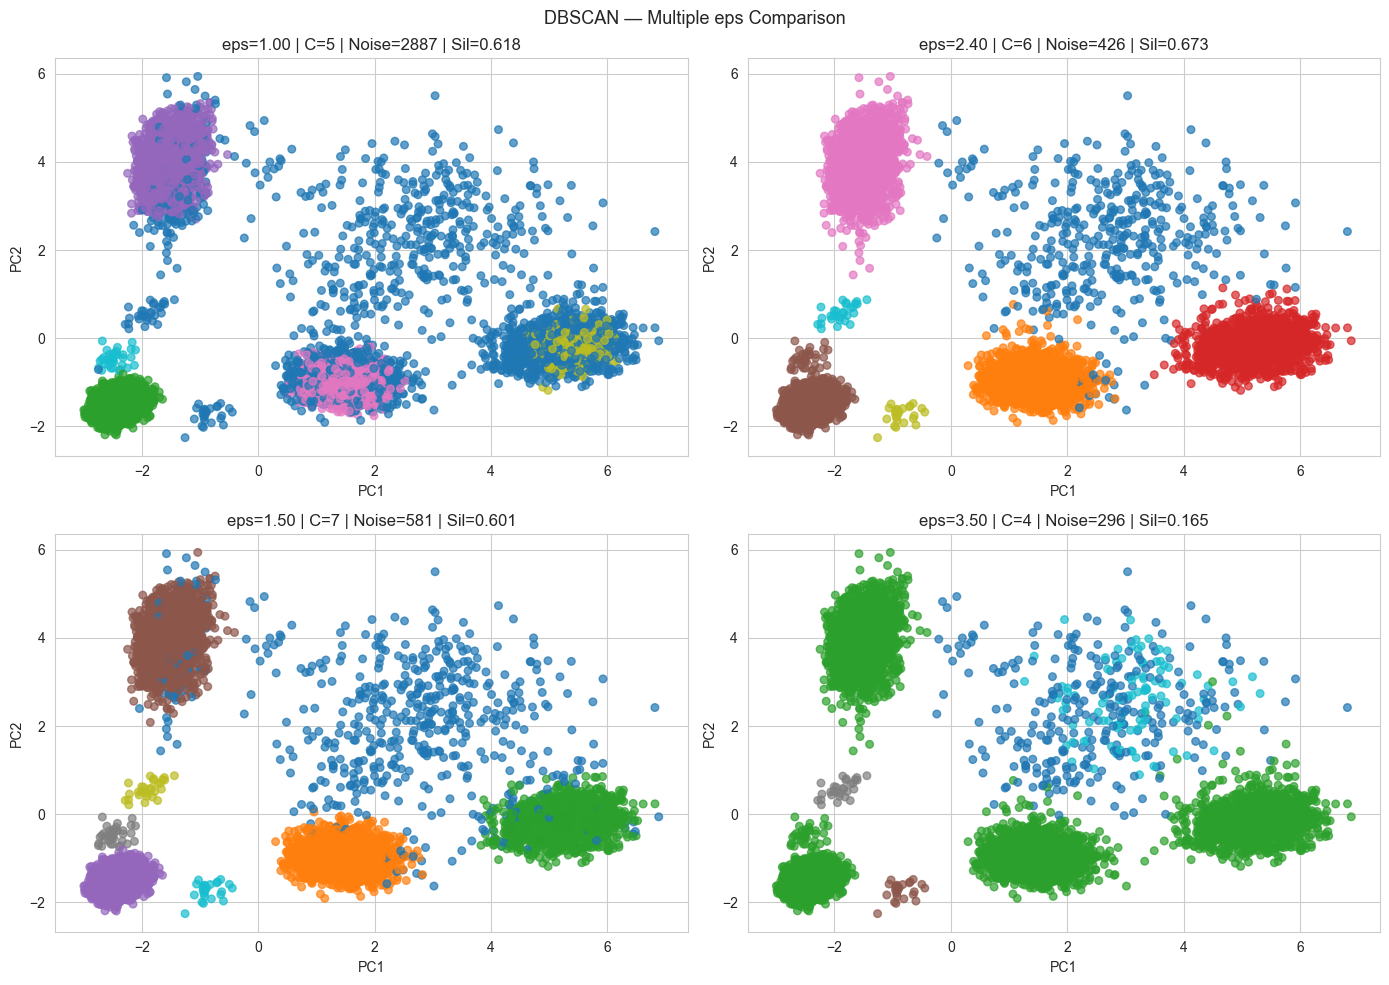

In [130]:
# Multiple eps comparison
eps_values = [1.0, best_eps, 1.5, 3.5]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, eps in zip(axes.flatten(), eps_values):
    db_tmp  = DBSCAN(eps=eps, min_samples=25).fit(scaled_array)
    lbls_tmp = db_tmp.labels_
    mask_tmp = lbls_tmp != -1
    score_tmp = silhouette_score(scaled_array[mask_tmp], lbls_tmp[mask_tmp]) \
                if len(set(lbls_tmp[mask_tmp])) > 1 else -1
    n_cl_tmp  = len(set(lbls_tmp)) - (1 if -1 in lbls_tmp else 0)
    n_ns_tmp  = (lbls_tmp == -1).sum()
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=lbls_tmp, cmap='tab10', s=30, alpha=0.7)
    ax.set_title(f'eps={eps:.2f} | C={n_cl_tmp} | Noise={n_ns_tmp} | Sil={score_tmp:.3f}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.suptitle('DBSCAN — Multiple eps Comparison', fontsize=13)
plt.tight_layout()
plt.show()

## GMM — Gaussian Mixture Models

**GMM** models the data as a mixture of Gaussian distributions. Unlike K-Means, it produces **soft (probabilistic) assignments** — each customer gets a probability of belonging to each cluster. This is especially useful when customer segments overlap.

**Advantages over K-Means:**
- Handles elliptical cluster shapes
- Soft assignments capture boundary uncertainty
- Model selection via **BIC** (lower = better fit with less complexity)

We run GMM on the autoencoder-compressed features for best results.

In [131]:
# GMM — BIC/AIC/Silhouette to select best k
k_range        = range(2, 11)
bic_scores     = []
aic_scores     = []
sil_scores_gmm = []

print('Fitting GMM on Autoencoder features...')
print(f"{'K':>4}  {'BIC':>12}  {'AIC':>12}  {'Silhouette':>12}")
print('-' * 46)

for k in k_range:
    gmm      = GaussianMixture(n_components=k, covariance_type='full', random_state=42, n_init=5)
    gmm.fit(df_encoded)
    labels_tmp = gmm.predict(df_encoded)
    bic = gmm.bic(df_encoded)
    aic = gmm.aic(df_encoded)
    sil = silhouette_score(df_encoded, labels_tmp)
    bic_scores.append(bic)
    aic_scores.append(aic)
    sil_scores_gmm.append(sil)
    print(f"{k:>4}  {bic:>12.2f}  {aic:>12.2f}  {sil:>12.4f}")

best_k_gmm = k_range[np.argmin(bic_scores)]
best_k_sil = k_range[np.argmax(sil_scores_gmm)]
print(f'\n✅ Best K by BIC       = {best_k_gmm}')
print(f'✅ Best K by Silhouette = {best_k_sil}')

Fitting GMM on Autoencoder features...
   K           BIC           AIC    Silhouette
----------------------------------------------
   2     155471.26     154813.23        0.4495
   3     103264.24     102273.50        0.6219
   4      70016.39      68692.94        0.6781
   5      55351.59      53695.43        0.6995
   6      55487.28      53498.41        0.4702
   7      48638.81      46317.23        0.5120
   8      47873.94      45219.65        0.5779
   9      47228.86      44241.86        0.2150
  10      47552.01      44232.29        0.4177

✅ Best K by BIC       = 9
✅ Best K by Silhouette = 5


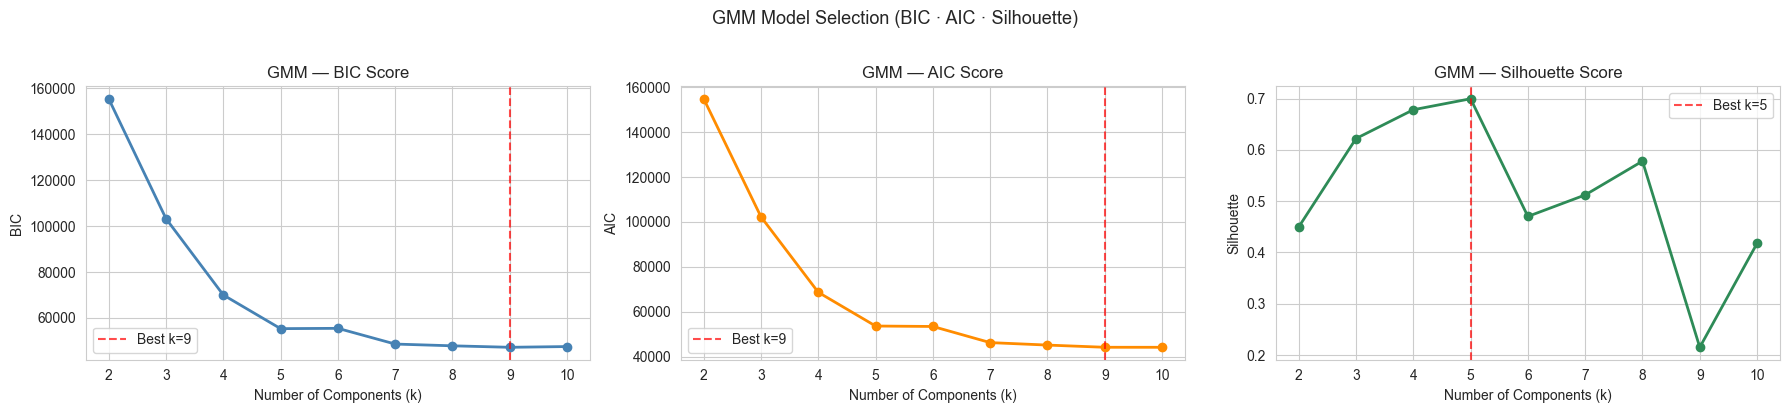

In [132]:
# BIC / AIC / Silhouette Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(k_range, bic_scores, marker='o', color='steelblue', linewidth=2)
axes[0].axvline(best_k_gmm, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_k_gmm}')
axes[0].set_title('GMM — BIC Score')
axes[0].set_xlabel('Number of Components (k)')
axes[0].set_ylabel('BIC')
axes[0].legend()

axes[1].plot(k_range, aic_scores, marker='o', color='darkorange', linewidth=2)
axes[1].axvline(best_k_gmm, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_k_gmm}')
axes[1].set_title('GMM — AIC Score')
axes[1].set_xlabel('Number of Components (k)')
axes[1].set_ylabel('AIC')
axes[1].legend()

axes[2].plot(k_range, sil_scores_gmm, marker='o', color='seagreen', linewidth=2)
axes[2].axvline(best_k_sil, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_k_sil}')
axes[2].set_title('GMM — Silhouette Score')
axes[2].set_xlabel('Number of Components (k)')
axes[2].set_ylabel('Silhouette')
axes[2].legend()

plt.suptitle('GMM Model Selection (BIC · AIC · Silhouette)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [133]:
# Fit Final GMM + Soft Probabilities
gmm_final  = GaussianMixture(n_components=best_k_sil, covariance_type='full', random_state=42, n_init=10)
gmm_final.fit(df_encoded)

gmm_labels = gmm_final.predict(df_encoded)
gmm_proba  = gmm_final.predict_proba(df_encoded)

sil_gmm_final = silhouette_score(df_encoded, gmm_labels)

print(f'GMM Components : {best_k_sil}')
print(f'BIC            : {gmm_final.bic(df_encoded):,.2f}')
print(f'Silhouette     : {sil_gmm_final:.4f}')
print()

unique, counts = np.unique(gmm_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c:5,}  ({c/len(gmm_labels)*100:.1f}%)')

df_gmm = df_clean.drop(columns=['CUST_ID'], errors='ignore').copy()
df_gmm['GMM_Cluster']         = gmm_labels
df_gmm['Assignment_Confidence'] = gmm_proba.max(axis=1)
print(f'\nAvg assignment confidence: {df_gmm["Assignment_Confidence"].mean():.2%}')

GMM Components : 5
BIC            : 55,351.59
Silhouette     : 0.6995

  Cluster 0: 4,566  (38.0%)
  Cluster 1: 2,869  (23.9%)
  Cluster 2: 2,265  (18.9%)
  Cluster 3: 1,736  (14.5%)
  Cluster 4:   575  (4.8%)

Avg assignment confidence: 99.98%


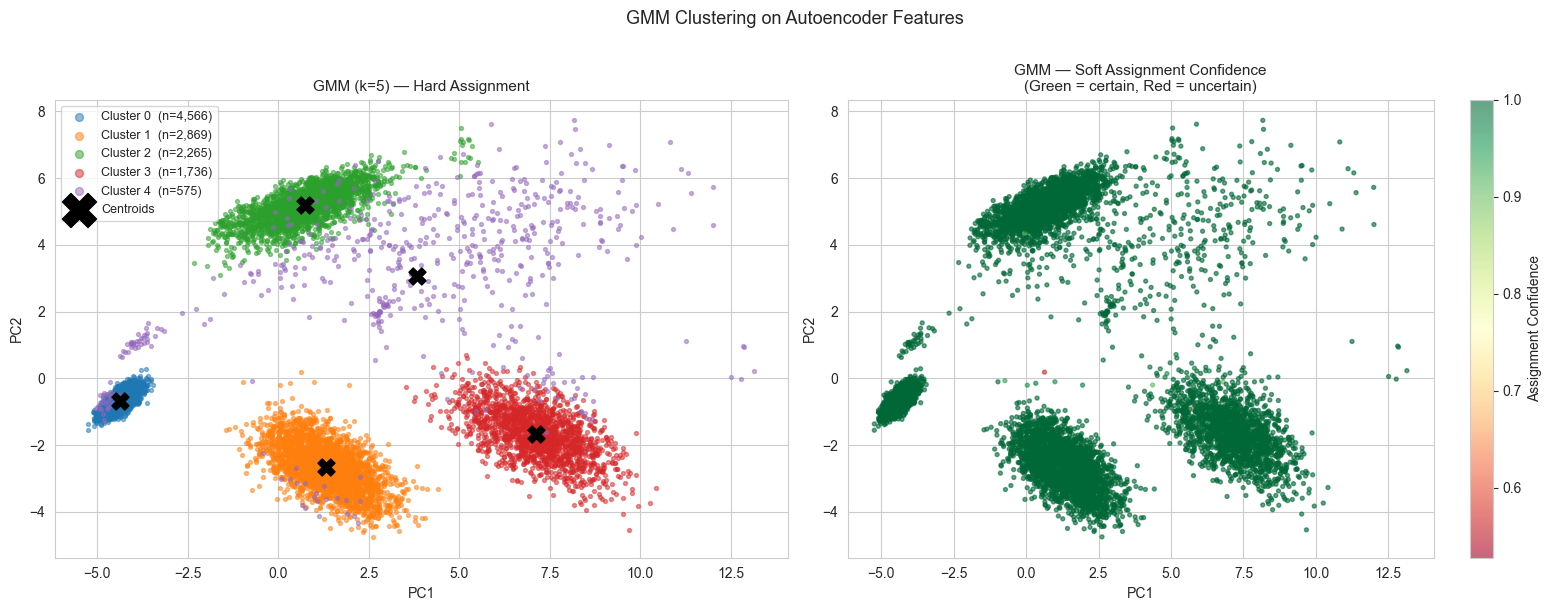

In [134]:
# PCA Visualization — GMM: Hard Assignment + Soft Confidence
pca_gmm        = PCA(n_components=2)
pca_result_gmm = pca_gmm.fit_transform(df_encoded)
centroids_pca_gmm = pca_gmm.transform(gmm_final.means_)
palette = plt.cm.tab10

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Hard Labels
for lbl in sorted(set(gmm_labels)):
    mask = gmm_labels == lbl
    axes[0].scatter(pca_result_gmm[mask, 0], pca_result_gmm[mask, 1],
                    c=[palette(lbl % 10)], s=8, alpha=0.5,
                    label=f'Cluster {lbl}  (n={mask.sum():,})')
axes[0].scatter(centroids_pca_gmm[:, 0], centroids_pca_gmm[:, 1],
                c='black', s=150, marker='X', zorder=5, label='Centroids')
axes[0].set_title(f'GMM (k={best_k_sil}) — Hard Assignment', fontsize=11)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=2, fontsize=9)

# Right: Soft Confidence Heatmap
sc = axes[1].scatter(pca_result_gmm[:, 0], pca_result_gmm[:, 1],
                     c=df_gmm['Assignment_Confidence'], cmap='RdYlGn', s=8, alpha=0.6)
plt.colorbar(sc, ax=axes[1], label='Assignment Confidence')
axes[1].set_title('GMM — Soft Assignment Confidence\n(Green = certain, Red = uncertain)', fontsize=11)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.suptitle('GMM Clustering on Autoencoder Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [135]:
# GMM Cluster Naming
profile_gmm_orig = df_clean.drop(
    columns=['CUST_ID','KMeans_Cluster_ID','KMeans_Cluster_Name',
             'AE_Cluster_ID','AE_Cluster_Name',
             'DBSCAN_Cluster_ID','DBSCAN_Cluster_Name'], errors='ignore').copy()
profile_gmm_orig['Cluster'] = gmm_labels
profile_gmm_means = profile_gmm_orig.groupby('Cluster').mean()

gmm_cluster_names = auto_name_clusters(profile_gmm_means)

print('GMM Cluster Names:')
for k, v in gmm_cluster_names.items():
    print(f'  Cluster {k} -> {v}')

df_clean['GMM_Cluster_ID']   = gmm_labels
df_clean['GMM_Cluster_Name'] = [gmm_cluster_names[l] for l in gmm_labels]

print(f'\nDistribution:')
print(df_clean['GMM_Cluster_Name'].value_counts())

GMM Cluster Names:
  Cluster 0 -> Low Activity
  Cluster 1 -> Installment Buyer
  Cluster 2 -> Cash Advance Heavy
  Cluster 3 -> Premium Spender
  Cluster 4 -> Active Shopper

Distribution:
GMM_Cluster_Name
Low Activity          4566
Installment Buyer     2869
Cash Advance Heavy    2265
Premium Spender       1736
Active Shopper         575
Name: count, dtype: int64


## SOM — Self-Organizing Maps

**SOM** is an unsupervised neural network that projects high-dimensional data onto a 2D grid while preserving topological structure (nearby nodes = similar data). Unlike other algorithms, it gives you:
- A **U-Matrix**: shows cluster boundaries (dark = boundary, light = dense region)
- A **Hit Map**: how many data points mapped to each neuron
- **BMU Distribution**: where each customer lands on the grid

We run a **grid search** to find optimal SOM parameters (grid size, sigma, learning rate, iterations).

In [136]:
# SOM Grid Search
X_scaled   = df_scaled.values
n_samples  = X_scaled.shape[0]
n_features = X_scaled.shape[1]
print(f'Samples: {n_samples:,}')
print(f'Features: {n_features}')

param_grid = {
    'grid_size'     : [(10,10), (12,12), (15,15), (18,18), (20,20)],
    'sigma'         : [1.0, 1.5, 2.0],
    'learning_rate' : [0.3, 0.5, 0.7],
    'num_iterations': [2000, 5000]
}

results_som = []
total_combos = (len(param_grid['grid_size']) * len(param_grid['sigma']) *
                len(param_grid['learning_rate']) * len(param_grid['num_iterations']))
print(f'Total combinations: {total_combos}')

for (gx, gy), sigma, lr, iterations in product(
        param_grid['grid_size'], param_grid['sigma'],
        param_grid['learning_rate'], param_grid['num_iterations']):
    som_tmp = MiniSom(gx, gy, n_features, sigma=sigma, learning_rate=lr, random_seed=42)
    som_tmp.random_weights_init(X_scaled)
    som_tmp.train(X_scaled, iterations, verbose=False)
    qe = som_tmp.quantization_error(X_scaled)
    te = som_tmp.topographic_error(X_scaled)
    results_som.append({'grid': f'{gx}x{gy}', 'sigma': sigma, 'lr': lr,
                        'iter': iterations, 'QE': qe, 'TE': te})
    print(f'{gx}x{gy:<3} | σ={sigma} | lr={lr} | iter={iterations} | QE={qe:.4f} | TE={te:.4f}')

results_df = pd.DataFrame(results_som)

best_qe       = results_df.loc[results_df['QE'].idxmin()]
best_te       = results_df.loc[results_df['TE'].idxmin()]
best_balanced = results_df.loc[
    (results_df['QE'] <= results_df['QE'].quantile(0.25)) &
    (results_df['TE'] <= results_df['TE'].quantile(0.25))
].iloc[0]

print('\nBEST PARAMETERS')
print(f'Lowest QE    : {best_qe["grid"]} | σ={best_qe["sigma"]} | lr={best_qe["lr"]} | QE={best_qe["QE"]:.4f}')
print(f'Lowest TE    : {best_te["grid"]} | σ={best_te["sigma"]} | lr={best_te["lr"]} | TE={best_te["TE"]:.4f}')
print(f'Most Balanced: {best_balanced["grid"]} | σ={best_balanced["sigma"]} | lr={best_balanced["lr"]} | QE={best_balanced["QE"]:.4f} | TE={best_balanced["TE"]:.4f}')

Samples: 12,011
Features: 17
Total combinations: 90
10x10  | σ=1.0 | lr=0.3 | iter=2000 | QE=1.0485 | TE=0.3669
10x10  | σ=1.0 | lr=0.3 | iter=5000 | QE=1.0125 | TE=0.4011
10x10  | σ=1.0 | lr=0.5 | iter=2000 | QE=1.0304 | TE=0.4780
10x10  | σ=1.0 | lr=0.5 | iter=5000 | QE=1.0101 | TE=0.4545
10x10  | σ=1.0 | lr=0.7 | iter=2000 | QE=1.0339 | TE=0.4780
10x10  | σ=1.0 | lr=0.7 | iter=5000 | QE=1.0116 | TE=0.5093
10x10  | σ=1.5 | lr=0.3 | iter=2000 | QE=1.0484 | TE=0.1330
10x10  | σ=1.5 | lr=0.3 | iter=5000 | QE=1.0325 | TE=0.1593
10x10  | σ=1.5 | lr=0.5 | iter=2000 | QE=1.0446 | TE=0.2213
10x10  | σ=1.5 | lr=0.5 | iter=5000 | QE=1.0310 | TE=0.2234
10x10  | σ=1.5 | lr=0.7 | iter=2000 | QE=1.0454 | TE=0.2443
10x10  | σ=1.5 | lr=0.7 | iter=5000 | QE=1.0375 | TE=0.2389
10x10  | σ=2.0 | lr=0.3 | iter=2000 | QE=1.0731 | TE=0.0752
10x10  | σ=2.0 | lr=0.3 | iter=5000 | QE=1.0615 | TE=0.0922
10x10  | σ=2.0 | lr=0.5 | iter=2000 | QE=1.0784 | TE=0.1036
10x10  | σ=2.0 | lr=0.5 | iter=5000 | QE=1.0667 

In [137]:
# Train final SOM with best balanced parameters
som = MiniSom(20, 20, n_features, sigma=2.0, learning_rate=0.3, random_seed=42)
som.random_weights_init(X_scaled)
som.train(X_scaled, 5000, verbose=False)

qe = som.quantization_error(X_scaled)
te = som.topographic_error(X_scaled)
print(f'QE: {qe:.4f}  (lower = better reconstruction)')
print(f'TE: {te:.4f}  (lower = better topology preservation)')

QE: 0.9318  (lower = better reconstruction)
TE: 0.1556  (lower = better topology preservation)


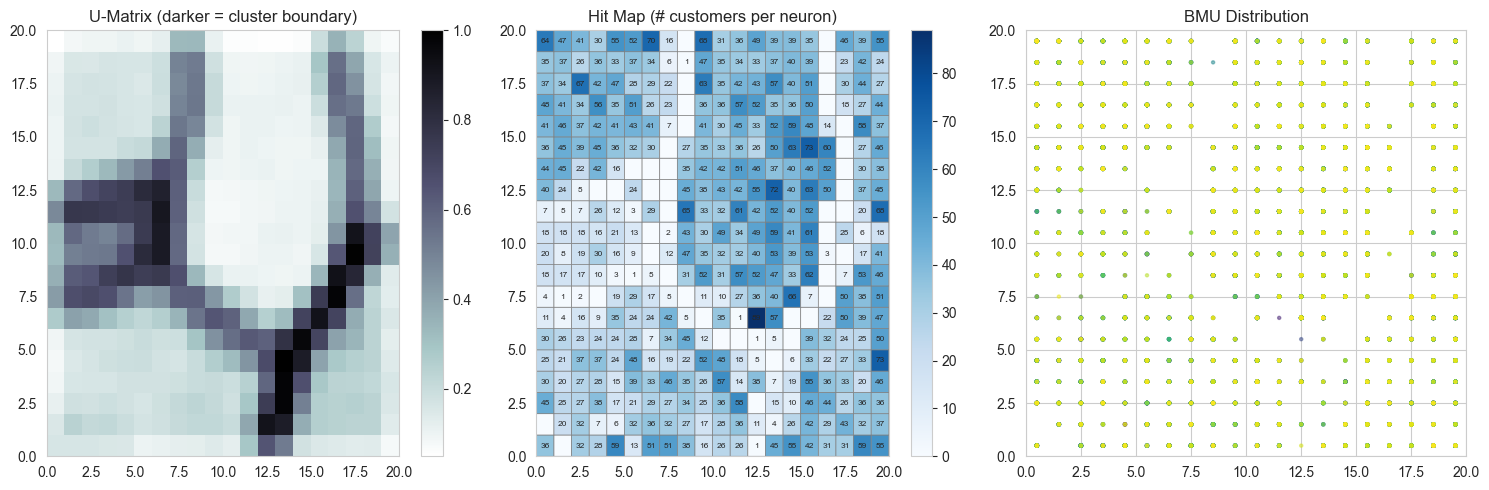

In [138]:
# SOM Visualization — U-Matrix, Hit Map, BMU Distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

umatrix = som.distance_map().T
axes[0].pcolor(umatrix, cmap='bone_r')
axes[0].set_title('U-Matrix (darker = cluster boundary)')
plt.colorbar(axes[0].collections[0], ax=axes[0])

hit_map = som.activation_response(X_scaled)
axes[1].pcolor(hit_map.T, cmap='Blues', edgecolors='gray', linewidth=0.5)
axes[1].set_title('Hit Map (# customers per neuron)')
plt.colorbar(axes[1].collections[0], ax=axes[1])
for i in range(hit_map.shape[0]):
    for j in range(hit_map.shape[1]):
        if hit_map[i, j] > 0:
            axes[1].text(i+0.5, j+0.5, str(int(hit_map[i,j])),
                         ha='center', va='center', fontsize=6)

bmu_positions = np.array([som.winner(x) for x in X_scaled])
axes[2].scatter(bmu_positions[:, 0]+0.5, bmu_positions[:, 1]+0.5,
                c=np.arange(len(bmu_positions)), cmap='viridis', alpha=0.5, s=5)
axes[2].set_title('BMU Distribution')
axes[2].set_xlim(0, 20)
axes[2].set_ylim(0, 20)

plt.tight_layout()
plt.show()

### SOM Cluster Naming

We assign each customer to a SOM cluster based on their BMU (Best Matching Unit) position. We use K-Means on the BMU grid coordinates to form discrete clusters, then apply `auto_name_clusters` for business interpretation.

## Final Summary & Export

Collect all cluster assignments (from all 4 algorithms) into one dataframe and save to CSV.

In [139]:
# Final DataFrame — all cluster assignments
final_cols = [
    'CUST_ID',
    'KMeans_Cluster_ID',  'KMeans_Cluster_Name',
    'AE_Cluster_ID',      'AE_Cluster_Name',
    'DBSCAN_Cluster_ID',  'DBSCAN_Cluster_Name',
    'GMM_Cluster_ID',     'GMM_Cluster_Name',
    
]

df_clusters = df_clean[[c for c in final_cols if c in df_clean.columns]].copy()
print('Final Cluster Assignments:')
print(df_clusters.head(10).to_string(index=False))

# Save results
df_results = features.copy()
df_results.insert(0, 'CUST_ID', df_clean['CUST_ID'].values)
df_results['NEURON_X']         = bmu_positions[:, 0]
df_results['NEURON_Y']         = bmu_positions[:, 1]
df_results['KMeans_Cluster']   = df_clean['KMeans_Cluster_Name'].values
df_results['AE_Cluster']       = df_clean['AE_Cluster_Name'].values
df_results['DBSCAN_Cluster']   = df_clean['DBSCAN_Cluster_Name'].values
df_results['GMM_Cluster']      = df_clean['GMM_Cluster_Name'].values


df_results.to_csv('customer_segments_final.csv', index=False)


Final Cluster Assignments:
CUST_ID  KMeans_Cluster_ID KMeans_Cluster_Name  AE_Cluster_ID    AE_Cluster_Name  DBSCAN_Cluster_ID DBSCAN_Cluster_Name  GMM_Cluster_ID   GMM_Cluster_Name
 C30077                  3   Installment Buyer              3  Installment Buyer                  0   Installment Buyer               1  Installment Buyer
 C29345                  0     Premium Spender              0    Premium Spender                  1  Cash Advance Heavy               3    Premium Spender
 C23726                  0     Premium Spender              0    Premium Spender                  1  Cash Advance Heavy               3    Premium Spender
 C28521                  1        Low Activity              1       Low Activity                  2           Segment 2               0       Low Activity
 C30497                  1        Low Activity              1       Low Activity                  2           Segment 2               0       Low Activity
 C29069                  2  Cash Advance He